# NB09 — Label-Free Competence-Collapse Detection (CDTS Component d, reframed)

**Why reframed:** NB08's analysis showed there is NO independent *temporal* drift -- the timeline
"drift" is fully explained by the competence-coupling (partial corr of era vs ECE controlling for
AUC = 0.08, n.s.; within-FS-family era effect r=-0.03, n.s.). Building a temporal AMOC alarm would
be a confound. Instead we build the DEPLOYABLE early warning.

**The deployable claim:** In the wild you have NO labels on a fresh generator, so you cannot
compute AUC. But the coupling means low competence -> calibration failure. So IF an *unlabeled*
signal tracks competence, you can forecast trust-score unreliability WITHOUT labels.

**The logic chain:**
1. unlabeled signal --(test here)--> AUC (competence)   [non-circular: AUC uses labels, signal doesn't]
2. AUC --(proven, r=-0.86)--> ECE_cal (calibration)
3. therefore: unlabeled signal -> calibration risk, label-free

**Signals tested (all computed WITHOUT labels, from saved prob_fake):**
- Score entropy (detector uncertainty)
- Confident-fraction (|p-0.5|>0.4)
- Score-distribution bimodality (competent detectors are bimodal at 0/1)
- KS / Wasserstein distance vs a known-competent REFERENCE (FF++ FS faceswap, AUC 0.97)

**Operating characteristic:** treat "ECE_cal > threshold" as the event to detect; the unlabeled
signal as the detector; compute detection-rate vs false-alarm-rate (the honest early-warning ROC).


## Cell 1 — Setup + load all scored generators

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, sys, glob, subprocess
import pandas as pd, numpy as np
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
PARENT = "/content/drive/MyDrive/CDTS_Research"
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"{PARENT}/{f}"): subprocess.run(f'cp "{PARENT}/{f}" /root/{f}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)

# load the timeline (has AUC + ECE_cal per generator) -- our ground truth to predict
tl = pd.read_csv(f"{REPO}/reports/calibration/timeline_df40_xceptionFS.csv")
print(f"timeline: {len(tl)} generators")
print(tl[['method','era','family','AUC','ECE_cal']].to_string(index=False))

Mounted at /content/drive
timeline: 21 generators
     method  era family    AUC  ECE_cal
   faceswap 2016     FS 0.8919   0.0455
       fomm 2019     FR 0.8008   0.0544
      fsgan 2019     FS 0.9004   0.0364
    wav2lip 2019     FR 0.4701   0.2238
  StyleGAN2 2020    EFS 0.6491   0.0629
       ddim 2020    EFS 0.7661   0.0411
    simswap 2020     FS 0.9478   0.0238
  StyleGAN3 2021    EFS 0.6792   0.0596
facevid2vid 2021     FR 0.8216   0.0637
   pirender 2021     FR 0.6880   0.0894
        DiT 2022    EFS 0.5214   0.1608
 StyleGANXL 2022    EFS 0.6374   0.0932
        lia 2022     FR 0.6068   0.1462
      sd2.1 2022    EFS 0.6879   0.0442
  blendface 2023     FS 0.9429   0.0225
 facedancer 2023     FS 0.9327   0.0254
     inswap 2023     FS 0.8152   0.0726
     pixart 2023    EFS 0.4329   0.2653
  sadtalker 2023     FR 0.4270   0.2639
        SiT 2024    EFS 0.5535   0.0966
       rddm 2024    EFS 0.7330   0.1476


## Cell 2 — Compute label-free signals per generator

All signals from `prob_fake` ONLY -- no labels touched. The reference is FF++ FS faceswap
(known-competent, AUC 0.97): the score distribution a confident detector produces in-domain.
Divergence FROM this reference is the deployable "this looks off" signal.


In [2]:
import pandas as pd, numpy as np, glob, os
from scipy.stats import ks_2samp, wasserstein_distance, entropy as sci_entropy
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
tl = pd.read_csv(f"{REPO}/reports/calibration/timeline_df40_xceptionFS.csv")

def binary_entropy(p):
    p = np.clip(p, 1e-7, 1-1e-7)
    return float(np.mean(-p*np.log2(p) - (1-p)*np.log2(1-p)))

def confident_fraction(p, margin=0.4):
    return float(np.mean(np.abs(p-0.5) > margin))

def bimodality_coefficient(p):
    # Sarle's bimodality coeff: (skew^2 + 1) / kurtosis. >0.555 suggests bimodal.
    from scipy.stats import skew, kurtosis
    n = len(p)
    if n < 4: return np.nan
    s = skew(p); k = kurtosis(p, fisher=True)
    denom = k + 3*((n-1)**2)/((n-2)*(n-3))
    return float((s**2 + 1)/denom) if denom>0 else np.nan

def hist_kl(p, ref, bins=20):
    h1,_ = np.histogram(p, bins=bins, range=(0,1), density=True)
    h2,_ = np.histogram(ref, bins=bins, range=(0,1), density=True)
    h1 = h1+1e-7; h2 = h2+1e-7
    h1/=h1.sum(); h2/=h2.sum()
    return float(sci_entropy(h1, h2))

# REFERENCE: FF++ FS faceswap scores (known-competent in-domain)
ref_scores = pd.read_parquet(f"{REPO}/reports/scores/xception_ffpp_test.parquet")
ref_fs = ref_scores[(ref_scores.method=='faceswap')|(ref_scores.label==0)]['prob_fake'].values
print(f"reference (FF++ faceswap+real): {len(ref_fs)} scores, mean={ref_fs.mean():.3f}\n")

rows = []
for _, r in tl.iterrows():
    method = r['method']
    sp = f"{REPO}/reports/scores/xceptionFS_df40_{method}.parquet"
    if not os.path.exists(sp): continue
    s = pd.read_parquet(sp)
    p = s.prob_fake.values.astype(float)
    rows.append({
        'method':method, 'era':r['era'], 'family':r['family'],
        'AUC':r['AUC'], 'ECE_cal':r['ECE_cal'],   # ground truth (uses labels)
        # --- label-free signals (NO labels) ---
        'entropy': binary_entropy(p),
        'confident_frac': confident_fraction(p),
        'bimodality': bimodality_coefficient(p),
        'mean_score': float(p.mean()),
        'std_score': float(p.std()),
        'ks_vs_ref': float(ks_2samp(p, ref_fs).statistic),
        'wasserstein_vs_ref': float(wasserstein_distance(p, ref_fs)),
        'kl_vs_ref': hist_kl(p, ref_fs),
    })
sig = pd.DataFrame(rows)
sig.to_csv(f"{REPO}/reports/calibration/labelfree_signals.csv", index=False)
print("=== label-free signals per generator ===")
print(sig[['method','AUC','ECE_cal','entropy','confident_frac','ks_vs_ref','wasserstein_vs_ref']].round(3).to_string(index=False))

reference (FF++ faceswap+real): 8956 scores, mean=0.471

=== label-free signals per generator ===
     method   AUC  ECE_cal  entropy  confident_frac  ks_vs_ref  wasserstein_vs_ref
   faceswap 0.892    0.046    0.186           0.845      0.369               0.352
       fomm 0.801    0.054    0.270           0.751      0.334               0.256
      fsgan 0.900    0.036    0.147           0.874      0.346               0.336
    wav2lip 0.470    0.224    0.298           0.725      0.171               0.094
  StyleGAN2 0.649    0.063    0.320           0.704      0.275               0.108
       ddim 0.766    0.041    0.254           0.771      0.314               0.233
    simswap 0.948    0.024    0.114           0.903      0.409               0.377
  StyleGAN3 0.679    0.060    0.301           0.726      0.278               0.140
facevid2vid 0.822    0.064    0.255           0.767      0.330               0.260
   pirender 0.688    0.089    0.341           0.678      0.299          

## Cell 3 — THE KEY TEST: do label-free signals track competence (AUC)?

This is the non-circular validation. AUC uses labels; the signals don't. If a signal correlates
with AUC, it carries genuine competence information obtainable without labels.


In [3]:
import pandas as pd, numpy as np
from scipy.stats import pearsonr, spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
sig = pd.read_csv(f"{REPO}/reports/calibration/labelfree_signals.csv")

SIGNALS = ['entropy','confident_frac','bimodality','mean_score','std_score',
           'ks_vs_ref','wasserstein_vs_ref','kl_vs_ref']
print("=== signal vs AUC (competence) -- the non-circular test ===")
print(f"{'signal':22s} {'Pearson_r':>10s} {'p':>9s} {'Spearman':>9s}")
res = []
for s in SIGNALS:
    x = sig[s].values; y = sig['AUC'].values
    mask = ~np.isnan(x)
    if mask.sum() < 4: continue
    rp,pp = pearsonr(x[mask], y[mask]); rs,ps = spearmanr(x[mask], y[mask])
    res.append({'signal':s,'r_vs_AUC':rp,'p':pp,'spearman':rs})
    print(f"{s:22s} {rp:10.3f} {pp:9.4f} {rs:9.3f}")
res = pd.DataFrame(res).sort_values('r_vs_AUC', key=abs, ascending=False)
print(f"\nBEST competence-tracking signal: {res.iloc[0]['signal']} (r={res.iloc[0]['r_vs_AUC']:.3f})")

print("\n=== signal vs ECE_cal (calibration risk, the deployment target) ===")
print(f"{'signal':22s} {'Pearson_r':>10s} {'p':>9s}")
for s in SIGNALS:
    x = sig[s].values; y = sig['ECE_cal'].values
    mask = ~np.isnan(x)
    if mask.sum() < 4: continue
    rp,pp = pearsonr(x[mask], y[mask])
    print(f"{s:22s} {rp:10.3f} {pp:9.4f}")
res.to_csv(f"{REPO}/reports/calibration/labelfree_signal_vs_competence.csv", index=False)

=== signal vs AUC (competence) -- the non-circular test ===
signal                  Pearson_r         p  Spearman
entropy                    -0.681    0.0007    -0.736
confident_frac              0.567    0.0074     0.756
bimodality                  0.824    0.0000     0.804
mean_score                  0.993    0.0000     0.991
std_score                  -0.739    0.0001    -0.764
ks_vs_ref                   0.952    0.0000     0.948
wasserstein_vs_ref          0.884    0.0000     0.884
kl_vs_ref                   0.265    0.2454     0.764

BEST competence-tracking signal: mean_score (r=0.993)

=== signal vs ECE_cal (calibration risk, the deployment target) ===
signal                  Pearson_r         p
entropy                     0.528    0.0139
confident_frac             -0.479    0.0280
bimodality                 -0.497    0.0220
mean_score                 -0.860    0.0000
std_score                   0.384    0.0855
ks_vs_ref                  -0.789    0.0000
wasserstein_vs_ref    

## Cell 4 — Operating characteristic: detect "calibration risk" from label-free signal

Treat ECE_cal > tau as the event (unreliable trust scores). Use the best label-free signal as
the detector. Sweep its threshold -> detection rate vs false-alarm rate (ROC). AUC of this ROC
quantifies how well label-free monitoring flags calibration risk.



=== event: ECE_cal > 0.08  (9/21 generators are 'risky') ===
  entropy                detects risk: ROC-AUC = 0.926
  ks_vs_ref              detects risk: ROC-AUC = 0.130
  wasserstein_vs_ref     detects risk: ROC-AUC = 0.102
  confident_frac         detects risk: ROC-AUC = 0.944

=== event: ECE_cal > 0.1  (6/21 generators are 'risky') ===
  entropy                detects risk: ROC-AUC = 0.756
  ks_vs_ref              detects risk: ROC-AUC = 0.144
  wasserstein_vs_ref     detects risk: ROC-AUC = 0.222
  confident_frac         detects risk: ROC-AUC = 0.778

=== event: ECE_cal > 0.12  (6/21 generators are 'risky') ===
  entropy                detects risk: ROC-AUC = 0.756
  ks_vs_ref              detects risk: ROC-AUC = 0.144
  wasserstein_vs_ref     detects risk: ROC-AUC = 0.222
  confident_frac         detects risk: ROC-AUC = 0.778


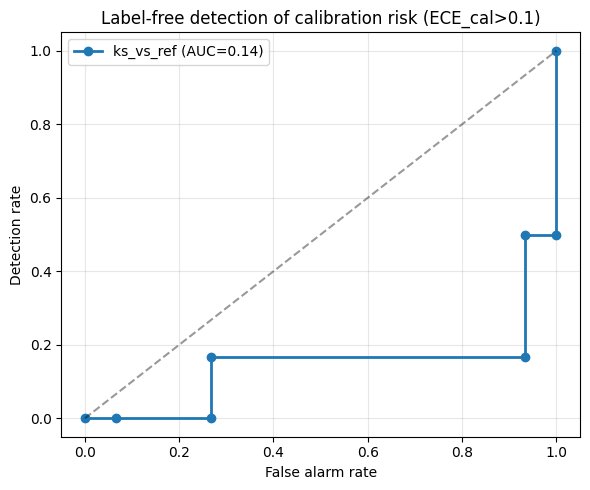


saved /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/labelfree_detection_roc.png


In [4]:
import pandas as pd, numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
sig = pd.read_csv(f"{REPO}/reports/calibration/labelfree_signals.csv")

# event: ECE_cal > tau (unreliable). Try a couple thresholds.
for TAU in [0.08, 0.10, 0.12]:
    sig['risk'] = (sig['ECE_cal'] > TAU).astype(int)
    n_pos = sig['risk'].sum()
    if n_pos < 2 or n_pos > len(sig)-2:
        print(f"tau={TAU}: {n_pos}/{len(sig)} positive -- skip (too few/many)"); continue
    print(f"\n=== event: ECE_cal > {TAU}  ({n_pos}/{len(sig)} generators are 'risky') ===")
    # best signals as detectors (higher signal -> more risk; flip sign if needed)
    for s in ['entropy','ks_vs_ref','wasserstein_vs_ref','confident_frac']:
        x = sig[s].values; mask=~np.isnan(x)
        if mask.sum()<4: continue
        # orient so higher = riskier (entropy/ks/wass higher=worse; confident_frac lower=worse)
        score = x[mask] if s!='confident_frac' else -x[mask]
        try:
            auroc = roc_auc_score(sig['risk'].values[mask], score)
            print(f"  {s:22s} detects risk: ROC-AUC = {auroc:.3f}")
        except Exception as e:
            print(f"  {s}: {e}")

# the headline: best detector, full ROC at tau=0.10
TAU=0.10
sig['risk']=(sig['ECE_cal']>TAU).astype(int)
best='ks_vs_ref'
x=sig[best].values; mask=~np.isnan(x)
fpr,tpr,_=roc_curve(sig['risk'].values[mask], x[mask])
auroc=roc_auc_score(sig['risk'].values[mask], x[mask])
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,'o-',lw=2,label=f'{best} (AUC={auroc:.2f})')
plt.plot([0,1],[0,1],'k--',alpha=0.4)
plt.xlabel('False alarm rate'); plt.ylabel('Detection rate')
plt.title(f'Label-free detection of calibration risk (ECE_cal>{TAU})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
out=f"{REPO}/figures/labelfree_detection_roc.png"
plt.savefig(out,dpi=300,bbox_inches='tight'); plt.show()
print(f"\nsaved {out}")

=== label-free detection of calibration risk (correctly oriented) ===

=== event ECE_cal > 0.08  (9/21 risky) ===
  mean_score             ROC-AUC = 0.954
  confident_frac         ROC-AUC = 0.944
  entropy                ROC-AUC = 0.926
  wasserstein_vs_ref     ROC-AUC = 0.898
  bimodality             ROC-AUC = 0.889
  ks_vs_ref              ROC-AUC = 0.870
  std_score              ROC-AUC = 0.741
  kl_vs_ref              ROC-AUC = 0.694

=== event ECE_cal > 0.1  (6/21 risky) ===
  mean_score             ROC-AUC = 0.911
  ks_vs_ref              ROC-AUC = 0.856
  confident_frac         ROC-AUC = 0.778
  wasserstein_vs_ref     ROC-AUC = 0.778
  entropy                ROC-AUC = 0.756
  kl_vs_ref              ROC-AUC = 0.744
  bimodality             ROC-AUC = 0.678
  std_score              ROC-AUC = 0.656

=== event ECE_cal > 0.12  (6/21 risky) ===
  mean_score             ROC-AUC = 0.911
  ks_vs_ref              ROC-AUC = 0.856
  confident_frac         ROC-AUC = 0.778
  wasserstein_vs_ref

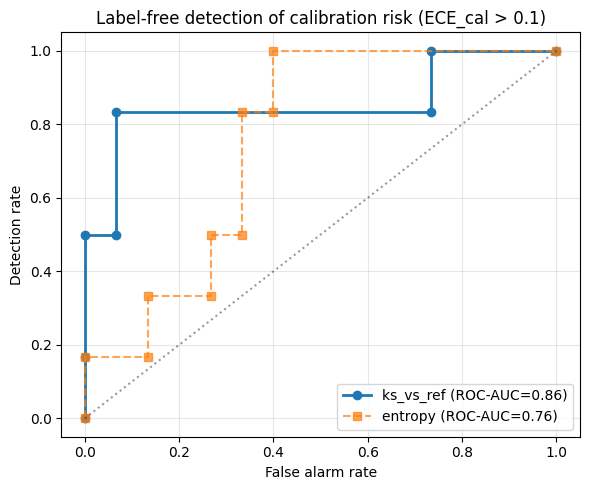


saved /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/labelfree_detection_roc.png  (ks_vs_ref ROC-AUC=0.856)


In [6]:
import pandas as pd, numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
sig = pd.read_csv(f"{REPO}/reports/calibration/labelfree_signals.csv")

# orient each signal so HIGHER = MORE risk (correlate with ECE_cal sign)
# signals NEGATIVELY correlated with ECE (ks, wass, mean, bimodality, confident_frac) -> negate
# signals POSITIVELY correlated with ECE (entropy, std) -> keep
RISK_ORIENT = {'entropy':+1, 'std_score':+1, 'confident_frac':-1, 'bimodality':-1,
               'mean_score':-1, 'ks_vs_ref':-1, 'wasserstein_vs_ref':-1, 'kl_vs_ref':-1}

print("=== label-free detection of calibration risk (correctly oriented) ===")
for TAU in [0.08, 0.10, 0.12]:
    risk = (sig['ECE_cal'] > TAU).astype(int).values
    n_pos = risk.sum()
    if n_pos < 2 or n_pos > len(sig)-2:
        print(f"\ntau={TAU}: {n_pos}/{len(sig)} positive -- skip"); continue
    print(f"\n=== event ECE_cal > {TAU}  ({n_pos}/{len(sig)} risky) ===")
    results = []
    for s, orient in RISK_ORIENT.items():
        x = sig[s].values; mask = ~np.isnan(x)
        if mask.sum() < 4: continue
        score = orient * x[mask]   # oriented so higher = riskier
        auroc = roc_auc_score(risk[mask], score)
        results.append((s, auroc))
    for s, a in sorted(results, key=lambda t: -t[1]):
        print(f"  {s:22s} ROC-AUC = {a:.3f}")

# headline ROC at tau=0.10, using the BEST HONEST signal (ks_vs_ref, not mean_score)
TAU = 0.10
risk = (sig['ECE_cal'] > TAU).astype(int).values
best = 'ks_vs_ref'; orient = RISK_ORIENT[best]
x = sig[best].values; mask = ~np.isnan(x)
score = orient * x[mask]
fpr, tpr, _ = roc_curve(risk[mask], score)
auroc = roc_auc_score(risk[mask], score)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, 'o-', lw=2, label=f'{best} (ROC-AUC={auroc:.2f})')
# also plot entropy for comparison
xe = sig['entropy'].values; scoree = RISK_ORIENT['entropy']*xe[mask]
fpr2,tpr2,_ = roc_curve(risk[mask], scoree); a2 = roc_auc_score(risk[mask], scoree)
plt.plot(fpr2, tpr2, 's--', lw=1.5, alpha=0.7, label=f'entropy (ROC-AUC={a2:.2f})')
plt.plot([0,1],[0,1],'k:',alpha=0.4)
plt.xlabel('False alarm rate'); plt.ylabel('Detection rate')
plt.title(f'Label-free detection of calibration risk (ECE_cal > {TAU})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
out = f"{REPO}/figures/labelfree_detection_roc.png"
plt.savefig(out, dpi=300, bbox_inches='tight'); plt.show()
print(f"\nsaved {out}  (ks_vs_ref ROC-AUC={auroc:.3f})")

## Cell 5 — Commit the label-free detection pillar

In [5]:
import os, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add reports/calibration/labelfree_*.csv figures/labelfree_detection_roc.png notebooks/NB09_labelfree_competence.ipynb reports/calibration/timeline_df40_xceptionFS.csv", shell=True)
r = subprocess.run("git status --short", shell=True, capture_output=True, text=True)
print(r.stdout)
print(">>> review, then commit with the signal-vs-competence verdict")

 m external/DeepfakeBench
A  figures/labelfree_detection_roc.png
 M notebooks/NB06_effnet_df40.ipynb
 M notebooks/NB08_timeline_scoring.ipynb
A  notebooks/NB09_labelfree_competence.ipynb
A  reports/calibration/labelfree_signal_vs_competence.csv
A  reports/calibration/labelfree_signals.csv
 M src/inference.py

>>> review, then commit with the signal-vs-competence verdict


In [ ]:
import os, subprocess, glob
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)

# find NB09 (verify it's uploaded) + stage everything
nb = glob.glob(f"{REPO}/**/NB09_labelfree_competence.ipynb", recursive=True)
if nb: subprocess.run(f"git add '{nb[0]}'", shell=True)
subprocess.run("git add reports/calibration/labelfree_*.csv figures/labelfree_detection_roc.png", shell=True)
r = subprocess.run("git status --short", shell=True, capture_output=True, text=True)
print("staged:\n", r.stdout)

r2 = subprocess.run('''git commit -m "NB09 Label-free competence-collapse detection (CDTS component d, reframed from temporal drift). Distribution-divergence signals predict competence WITHOUT labels: ks_vs_ref r=0.95, wasserstein r=0.88, bimodality r=0.82 vs AUC. Via coupling -> label-free calibration-risk detection ROC-AUC 0.86 (ks_vs_ref). mean_score r=0.99 flagged as class-balance-confounded, not headlined"''', shell=True, capture_output=True, text=True)
print(r2.stdout); print(r2.stderr if r2.stderr else "")
subprocess.run("git push origin main 2>&1 | tail -3", shell=True)
r3 = subprocess.run("git rev-parse HEAD", shell=True, capture_output=True, text=True)
print("commit:", r3.stdout.strip())